In [2]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [3]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



--- FIRST 5 ROWS ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    i

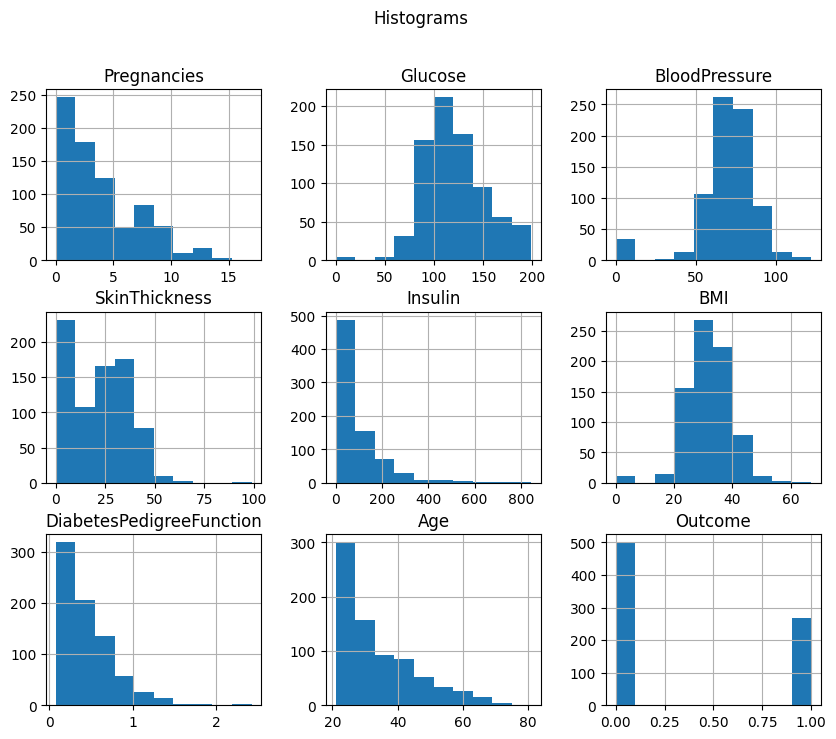

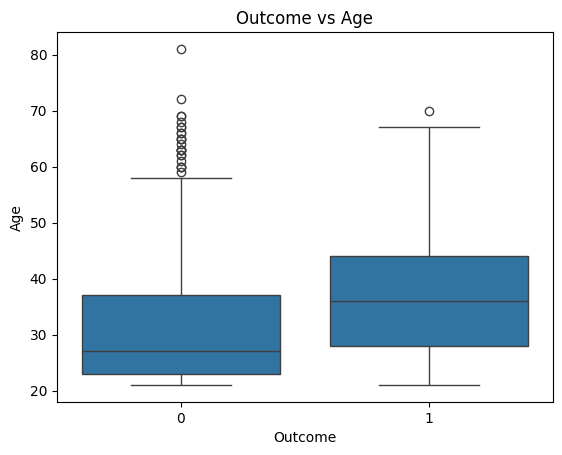

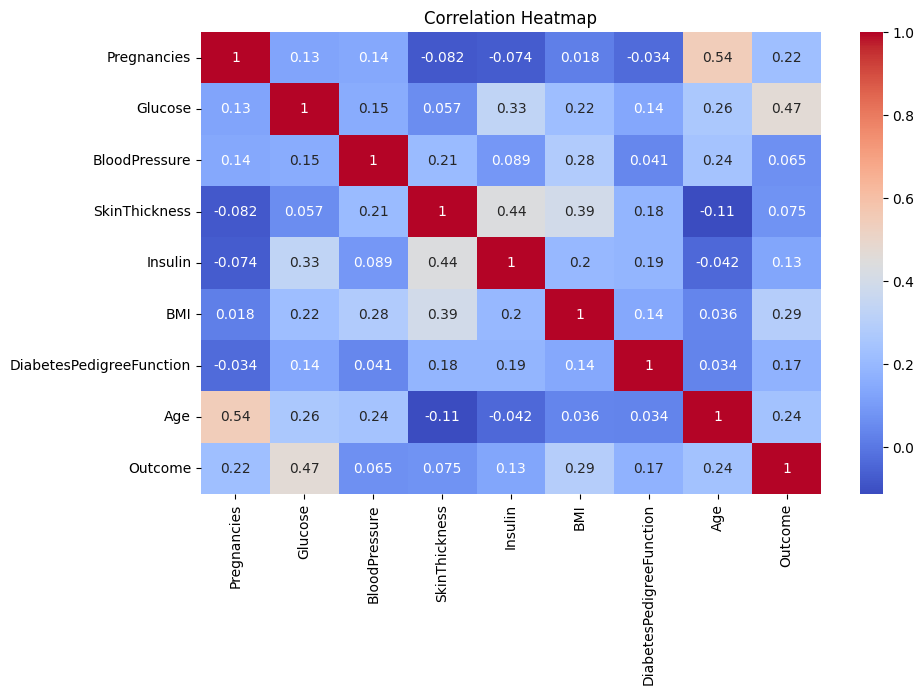

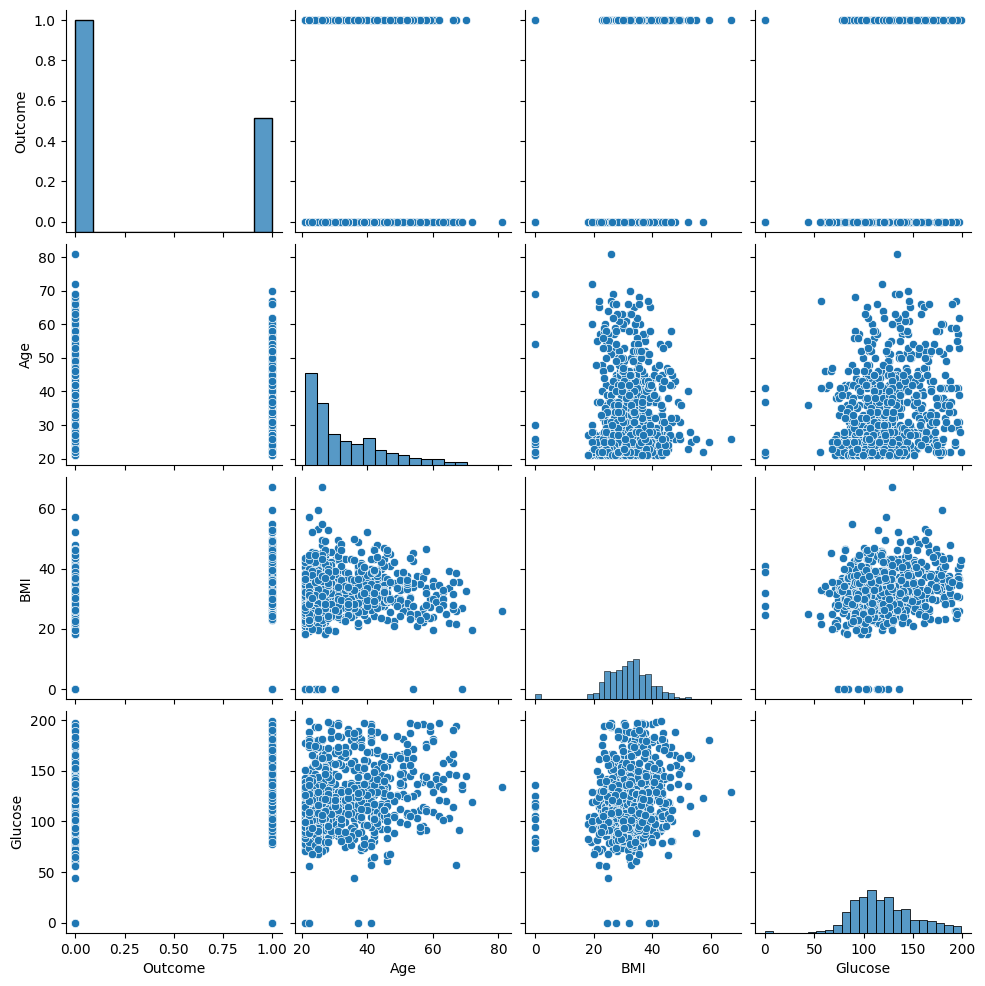


--- DATA AFTER PREPROCESSING ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

--- MODEL PERFORMANCE ---
Accuracy : 0.7467532467532467
Precision: 0.6379310344827587
Recall   : 0.6727272727272727
F1 Score : 0.6548672566371682
ROC-AUC  : 0.8128558310376492


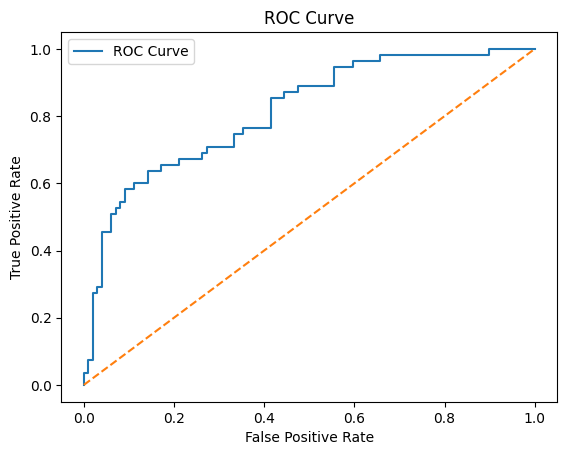


--- FEATURE IMPORTANCE ---
                    Feature  Coefficient
6  DiabetesPedigreeFunction     0.626718
5                       BMI     0.102607
0               Pregnancies     0.064373
7                       Age     0.037095
1                   Glucose     0.034095
3             SkinThickness     0.003291
4                   Insulin    -0.001803
2             BloodPressure    -0.013879

--- OBSERVATIONS ---
1. Positive coefficients increase survival probability.
2. Negative coefficients decrease survival probability.
3. Features like DiabetesPedigreeFunction, BMI, and Pregnancies strongly influence diabetes outcome.
4. Features like BloodPressure and Insulin typically have a negative impact on diabetes outcome.


In [6]:
    # ==============================
    # 1. IMPORT LIBRARIES
    # ==============================
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

    # ==============================
    # 2. LOAD DATASET
    # ==============================
    df = pd.read_csv("diabetes.csv")

    print("\n--- FIRST 5 ROWS ---")
    print(df.head())

    print("\n--- DATA INFO ---")
    print(df.info())

    print("\n--- SUMMARY STATISTICS ---")
    print(df.describe())

    # ==============================
    # 3. EXPLORATORY DATA ANALYSIS
    # ==============================

    # Histograms
    df.hist(figsize=(10,8))
    plt.suptitle("Histograms")
    plt.show()

    # Boxplot
    plt.figure()
    sns.boxplot(x='Outcome', y='Age', data=df) # Changed 'Survived' to 'Outcome'
    plt.title("Outcome vs Age")
    plt.show()

    # Correlation Heatmap
    plt.figure(figsize=(10,6))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
    plt.title("Correlation Heatmap")
    plt.show()

    # Pairplot
    sns.pairplot(df[['Outcome','Age','BMI','Glucose']]) # Changed 'Survived','Pclass','Age','Fare' to 'Outcome','Age','BMI','Glucose' for diabetes dataset
    plt.show()

    # ==============================
    # 4. DATA PREPROCESSING
    # ==============================

    # Handle missing values (Columns 'Age' and 'Embarked' are not in diabetes.csv, and 'Name','Ticket','Cabin' are not either. Removing these lines)
    # The diabetes dataset does not seem to have explicit missing values that require filling for Age or Embarked, nor does it have 'Name', 'Ticket', 'Cabin'.
    # If 0 values in Glucose, BloodPressure, SkinThickness, Insulin, BMI are considered missing, they would need imputation, but for now, assuming they are not explicitly missing.

    # Drop unnecessary columns (These columns are not in diabetes.csv. Removing these lines)
    # df.drop(['Name','Ticket','Cabin'], axis=1, inplace=True)

    # Encode categorical variables (Columns 'Sex' and 'Embarked' are not in diabetes.csv. Removing these lines)
    # df = pd.get_dummies(df, columns=['Sex','Embarked'], drop_first=True)

    print("\n--- DATA AFTER PREPROCESSING ---")
    print(df.head())

    # ==============================
    # 5. FEATURE SELECTION
    # ==============================
    X = df.drop('Outcome', axis=1) # Changed 'Survived' to 'Outcome'
    y = df['Outcome'] # Changed 'Survived' to 'Outcome'

    # ==============================
    # 6. TRAIN-TEST SPLIT
    # ==============================
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ==============================
    # 7. MODEL BUILDING
    # ==============================
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # ==============================
    # 8. PREDICTIONS
    # ==============================
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # ==============================
    # 9. MODEL EVALUATION
    # ==============================
    print("\n--- MODEL PERFORMANCE ---")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

    # ==============================
    # 10. ROC CURVE
    # ==============================
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # ==============================
    # 11. COEFFICIENT INTERPRETATION
    # ==============================
    coefficients = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': model.coef_[0]
    })

    print("\n--- FEATURE IMPORTANCE ---")
    print(coefficients.sort_values(by='Coefficient', ascending=False))

    # ==============================
    # 12. FINAL OBSERVATIONS (PRINT)
    # ==============================
    print("\n--- OBSERVATIONS ---")
    print("1. Positive coefficients increase survival probability.")
    print("2. Negative coefficients decrease survival probability.")
    print("3. Features like DiabetesPedigreeFunction, BMI, and Pregnancies strongly influence diabetes outcome.")
    print("4. Features like BloodPressure and Insulin typically have a negative impact on diabetes outcome.")

In [7]:
1. Difference between Precision and Recall
Precision = Correct Positive Predictions / Total Predicted Positives
 Focus: How accurate positive predictions are
Recall = Correct Positive Predictions / Actual Positives
Focus: How many actual positives are captured
Example:
Precision high → fewer false positives
Recall high → fewer false negatives

2. What is Cross-Validation?

Cross-validation is a technique where data is split into multiple parts (folds), and the model is trained and tested multiple times.

Example: K-Fold
Dataset split into K parts
Train on K-1, test on 1
Repeat K times
Importance:
Reduces overfitting
Gives more reliable performance
Uses full dataset efficiently

SyntaxError: invalid character '→' (U+2192) (916859330.py, line 7)